# Notebook 03 — The competition

Time to compete. Every team plays the **same game**:

- everyone starts from the **same** `N_INITIAL` measured antibodies,
- each round your wet lab tests exactly `BATCH_SIZE` new antibodies,
- you have `N_ROUNDS` rounds, and
- your goal is to **maximize hypervolume as fast as possible**.

The score is **AUC-HV** — the area under your hypervolume-vs-round curve, so
growing the front *early* matters, not just at the end. Ties break on final HV,
then number of non-dominated antibodies found, then diversity.

This is an **adaptive** campaign: you play **one round at a time**. After each
round you see the hypervolume you reached, then decide the *next* round's batch
plan in light of it — exactly like a real design–test–learn loop. Everything else
(the pool, oracle, initial design, batch size, round count) is locked.

## Locked setup (read-only)

These are fixed for every team — don't change them. We load the pool, the oracle
(noisy measurements only — `allow_true=False`), and the shared initial design.

In [1]:
import matplotlib.pyplot as plt
import torch

from mobo_lab import competition, config, data, metrics, plotting, seed
from mobo_lab.oracle import AntibodyOracle
from mobo_lab.pool import VHSequencePool

seed.set_all_seeds(config.SEED)

pool = VHSequencePool.from_files()
oracle = AntibodyOracle.from_files(allow_true=False)
initial_ids = data.load_initial_ids()

print("LOCKED competition settings")
print(f"  BATCH_SIZE = {config.BATCH_SIZE}  (antibodies per round)")
print(f"  N_ROUNDS   = {config.N_ROUNDS}    (rounds)")
print(f"  N_INITIAL  = {config.N_INITIAL}   (shared starting antibodies)")
print(f"  budget     = {config.TOTAL_NEW_EVALUATIONS} new evaluations total")
print(f"  pool size  = {len(pool)} candidate sequences")
print(f"  REF_POINT  = {config.REF_POINT}")

LOCKED competition settings
  BATCH_SIZE = 4  (antibodies per round)
  N_ROUNDS   = 6    (rounds)
  N_INITIAL  = 12   (shared starting antibodies)
  budget     = 24 new evaluations total
  pool size  = 2048 candidate sequences
  REF_POINT  = [-0.05, -0.05]


## ✏️ Start your campaign

Name your team and open a `Campaign`. It holds all the state (what's been measured,
the hypervolume so far) and enforces the rules for you every round: fixed
`BATCH_SIZE`, no duplicates, never re-measure an antibody.

Optionally switch the projection used for the continuous fallback with
`PROJECTION_METHOD` (`"nearest"` or `"diverse_nearest"`).

In [2]:
TEAM_NAME = "Team Example"
PROJECTION_METHOD = "nearest"

campaign = competition.Campaign(TEAM_NAME, projection_method=PROJECTION_METHOD)
print(f"{TEAM_NAME}: {campaign.rounds_left} rounds to play, starting HV = {campaign.current_hv:.4f}")

Team Example: 6 rounds to play, starting HV = 0.4209


## Play the rounds — one at a time, adapting as you go

Each round below: edit the **batch plan** (a dict whose slot counts add up to
`BATCH_SIZE`), run the cell, and read the hypervolume it reached. Then look at the
front and decide what to play next. The cards you can spend slots on:
`nehvi`, `parego`, `random`, `uncertainty`, and the fixed-preference family
`scalarized_<w1>_<w2>` — with `w1` on a dense grid `0.05, 0.10, …, 0.95` and
`w2 = 1 - w1` (e.g. `scalarized_0.05_0.95` leans hard on objective 2,
`scalarized_0.5_0.5` is balanced, `scalarized_0.95_0.05` leans hard on objective 1).

> Tip: `nehvi` chases the biggest hypervolume gain; `parego` spreads across the
> front; a fixed `scalarized_*` commits to one trade-off — pick the weight to aim
> at a *specific* part of the front; `random` / `uncertainty` spend a slot on
> exploration. Watch where the front has *gaps* and steer a scalarization there.

round 1/6  HV 0.4209 -> 0.6573  (+0.2364)  selected [1365, 921, 1371, 1069]


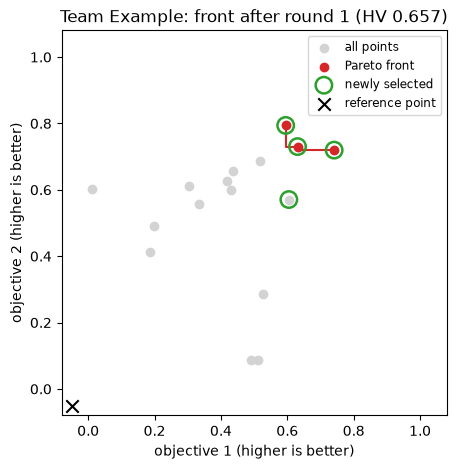

In [3]:
# --- Round 1 --------------------------------------------------------------
campaign.play_round({"nehvi": 4})
campaign.plot_front();

round 2/6  HV 0.6573 -> 0.8330  (+0.1757)  selected [86, 546, 431, 1803]


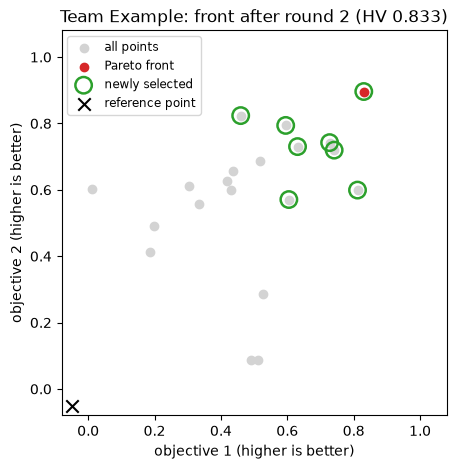

In [4]:
# --- Round 2 (edit after reading round 1) ---------------------------------
campaign.play_round({"nehvi": 3, "random": 1})
campaign.plot_front();

round 3/6  HV 0.8330 -> 0.9316  (+0.0987)  selected [1669, 134, 775, 1657]


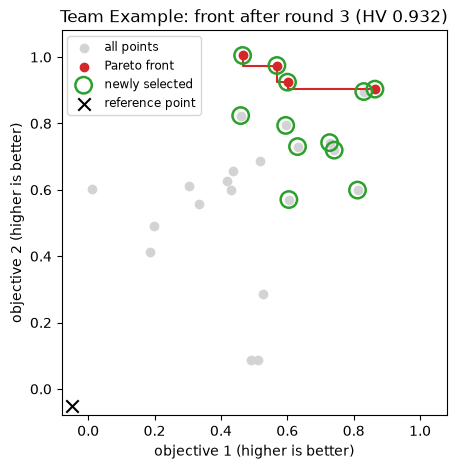

In [5]:
# --- Round 3 --------------------------------------------------------------
campaign.play_round({"parego": 4})
campaign.plot_front();

round 4/6  HV 0.9316 -> 0.9879  (+0.0562)  selected [1871, 1038, 481, 1362]


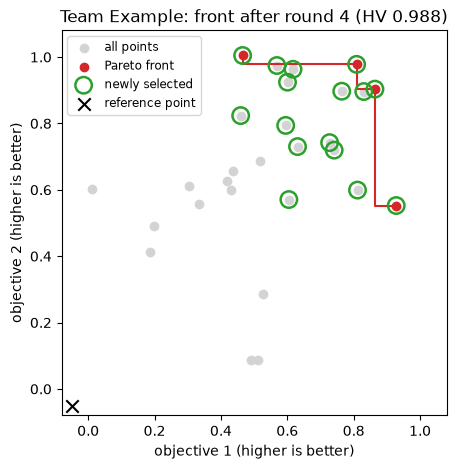

In [6]:
# --- Round 4 --------------------------------------------------------------
campaign.play_round({"nehvi": 2, "scalarized_0.5_0.5": 2})
campaign.plot_front();

round 5/6  HV 0.9879 -> 1.0227  (+0.0348)  selected [305, 774, 1396, 1286]


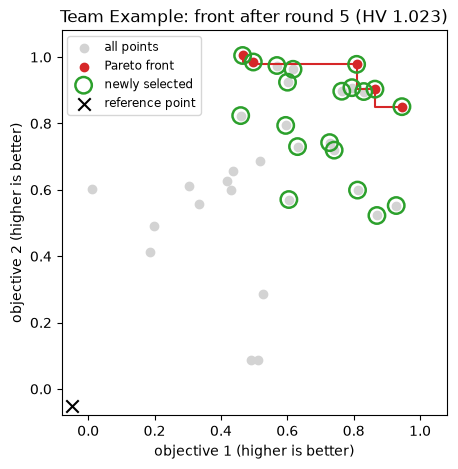

In [7]:
# --- Round 5 --------------------------------------------------------------
campaign.play_round({"nehvi": 4})
campaign.plot_front();

round 6/6  HV 1.0227 -> 1.0371  (+0.0144)  selected [402, 806, 299, 1283]


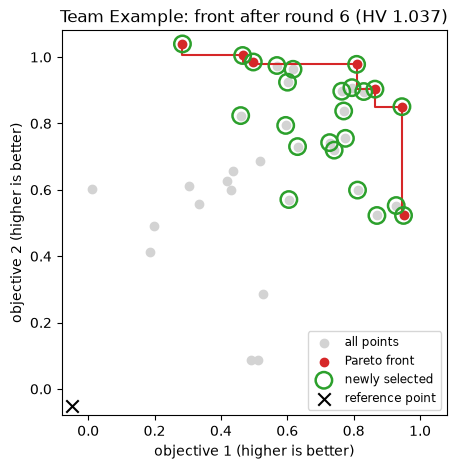

In [8]:
# --- Round 6 --------------------------------------------------------------
campaign.play_round({"nehvi": 4})
campaign.plot_front();

## Finalize and submit

Once all `N_ROUNDS` rounds are played, `finalize()` scores the campaign (AUC-HV)
and `save_run_outputs` writes your entry for the leaderboard.

In [9]:
history = campaign.finalize()
competition.save_run_outputs(history)

print(f"AUC-HV   : {history['auc_hv']:.4f}   <- the score")
print(f"final HV : {history['final_hv']:.4f}")
print(f"non-dominated antibodies found: {history['n_nondominated_selected']}")
print("HV by round:", [round(h, 4) for h in history["hv_history"]])

AUC-HV   : 0.8602   <- the score
final HV : 1.0371
non-dominated antibodies found: 7
HV by round: [0.4209, 0.6573, 0.833, 0.9316, 0.9879, 1.0227, 1.0371]


## Your results

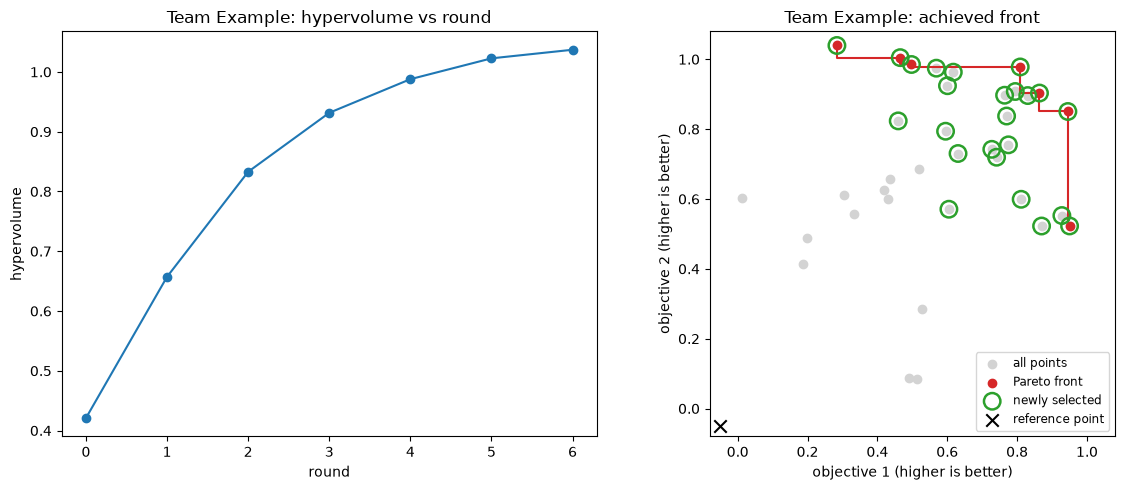

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plotting.plot_hv_curve(history["hv_history"], title=f"{TEAM_NAME}: hypervolume vs round", ax=axes[0])

final_Y = torch.tensor(history["final_Y"], dtype=torch.double)
selected = torch.zeros(final_Y.shape[0], dtype=torch.bool)
selected[history["n_initial"]:] = True
plotting.plot_pareto_front(
    final_Y, selected_mask=selected, ref_point=config.REF_POINT,
    title=f"{TEAM_NAME}: achieved front", ax=axes[1],
)
fig.tight_layout();

## How the front grew, round by round

Each round gets its own color: the filled dots are that round's newly measured
antibodies, and the staircase is the Pareto front achieved *through* that round.
Watch the front march outward — and see which rounds (which acquisition cards)
opened up new trade-offs versus filling in the interior.

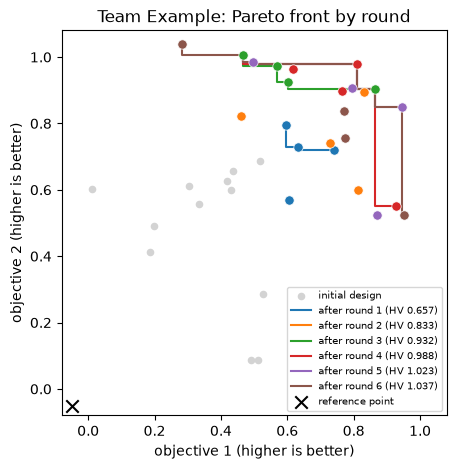

In [11]:
campaign.plot_fronts_by_round();

## Leaderboard

Once teams have saved their runs into `outputs/`, this ranks everyone by AUC-HV.
(Re-running your notebook overwrites your own entry — latest run wins.)

In [12]:
leaderboard = competition.update_leaderboard()
leaderboard

,team_name,auc_hv,final_hv,n_nondominated_selected,embedding_diversity
rank,,,,,
1,Team Example,0.860247,1.037111,7,0.517865


---
# Instructor section — the true Pareto front reveal

> Run by the instructor after the competition. It reconstructs the oracle with
> `allow_true=True` to expose the **hidden** objective landscape and overlay every
> team's achievement, turning the leaderboard into a scientific discussion.

true Pareto front: 7 points
wrote: /Users/jiwonpark/stage/multi-objective-reasoning-lab/outputs/final_true_pareto_overlay.png


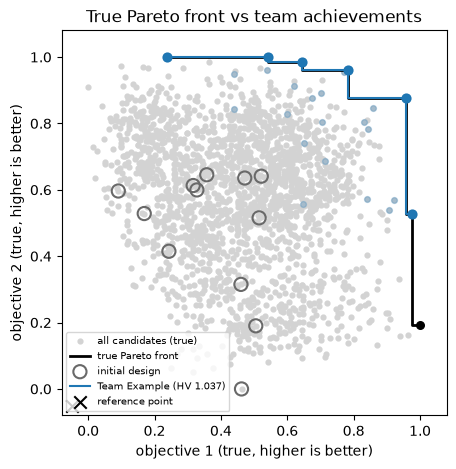

In [13]:
reveal_oracle = AntibodyOracle.from_files(allow_true=True)
true_front = metrics.compute_true_pareto_front(reveal_oracle.true_objectives)
print(f"true Pareto front: {true_front.shape[0]} points")

overlay_path = competition.build_final_debrief_report(
    config.OUTPUTS_DIR, reveal_oracle, initial_ids, config.REF_POINT
)
print("wrote:", overlay_path)

plotting.plot_true_front_with_team_overlays(
    reveal_oracle.true_objectives,
    initial_ids,
    competition.load_team_runs(),
    config.REF_POINT,
);

## Debrief prompts

With the true landscape visible, discuss:

1. **Which regions of the true front did teams find, and which did they miss?**
2. Where did a **fixed scalarization** over-focus — a corner exploited early but a
   chunk of the front left uncovered?
3. Where did **NEHVI / ParEGO** pay off, and where did spending a slot on
   **random / uncertainty** exploration uncover an otherwise-missed region?
4. Did `diverse_nearest` projection change which trade-offs a team reached?
5. Look at the AUC-HV vs final-HV ordering: did any team win the *race* (early HV)
   but not the *finish* (final HV), or vice versa? What does that say about their
   plan-per-round choices?